In [1]:
import torchaudio

waveform, sample_rate = torchaudio.load("../.cjk-data/Happy/1294_1256854279.mp3")
waveform = torchaudio.functional.resample(waveform, sample_rate, 32000)

In [2]:
from IPython.display import Audio
Audio(waveform.numpy(), rate=32000)


In [4]:
from panns_inference import AudioTagging
import numpy as np

model = AudioTagging(checkpoint_path=None, device='cpu')
audio = waveform.numpy()

clipwise_output, embedding = model.inference(audio)

--2026-09-07 16:18:16--  http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/class_labels_indices.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 2a00:1450:4001:c13::cf, 2a00:1450:4001:c21::cf, 2a00:1450:4001:c0f::cf, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|2a00:1450:4001:c13::cf|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14675 (14K) [application/octet-stream]
Saving to: ‘/home/cjk/panns_data/class_labels_indices.csv’

     0K .......... ....                                       100% 1,04M=0,01s

2026-09-07 16:18:16 (1,04 MB/s) - ‘/home/cjk/panns_data/class_labels_indices.csv’ saved [14675/14675]

--2026-09-07 16:18:16--  https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth?download=1


Checkpoint path: /home/cjk/panns_data/Cnn14_mAP=0.431.pth


Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving zenodo.org (zenodo.org)... 2001:1458:d00:17::100:1d9, 2001:1458:d00:24::100:245, 2001:1458:d00:3b::100:4d6, ...
Connecting to zenodo.org (zenodo.org)|2001:1458:d00:17::100:1d9|:443... connected.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-09-07 16:18:47--  (try: 2)  https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth?download=1
Reusing existing connection to [zenodo.org]:443.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/3987831/files/Cnn14_mAP=0.431.pth [following]
--2026-09-07 16:19:13--  https://zenodo.org/records/3987831/files/Cnn14_mAP=0.431.pth
Reusing existing connection to [zenodo.org]:443.
HTTP request sent, awaiting response... 200 OK
Length: 327428481 (312M) [application/octet-stream]
Saving to: ‘/home/cjk/panns_data/Cnn14_mAP=0.431.pth’

     0K .......... .......... .......... .......... ..........  0%  883K 6m2s
    50K .....

Using CPU.


In [5]:
print(embedding.shape)


(2, 2048)


In [6]:
import os
import librosa
import numpy as np
from panns_inference import AudioTagging

folder = "/home/cjk/code/CevenJKnowles/Kitty3000-ML/.cjk-data/Happy"

mp3_files = [f for f in os.listdir(folder) if f.endswith(".mp3")]
print(f"Found {len(mp3_files)} MP3 files in {folder}")

model = AudioTagging(checkpoint_path=None, device='cpu')

features = []
processed_files = []

for filename in mp3_files:
    path = os.path.join(folder, filename)
    audio, sr = librosa.load(path, sr=32000, mono=True)
    print(f"{filename}: {len(audio)} samples at {sr}Hz ({len(audio)/sr:.2f}s)")

    audio = audio[None, :]
    _, embedding = model.inference(audio)

    features.append(embedding[0])
    processed_files.append(filename)

X = np.vstack(features)

print("\n--- Summary ---")
print(f"Files processed: {len(processed_files)}")
print(f"Feature matrix shape: {X.shape}")
print(f"First file: {processed_files[0]}")
print(f"First embedding, first 5 values: {X[0][:5]}")

Found 594 MP3 files in /home/cjk/code/CevenJKnowles/Kitty3000-ML/.cjk-data/Happy
Checkpoint path: /home/cjk/panns_data/Cnn14_mAP=0.431.pth
Using CPU.
1294_1256854279.mp3: 28797 samples at 32000Hz (0.90s)
1294_1256854279_aug1(1).mp3: 28797 samples at 32000Hz (0.90s)
1295_1256854283.mp3: 29028 samples at 32000Hz (0.91s)
1295_1256854283_aug1(1).mp3: 29028 samples at 32000Hz (0.91s)
1296_1256854286.mp3: 22156 samples at 32000Hz (0.69s)
1296_1256854286_aug1(1).mp3: 22156 samples at 32000Hz (0.69s)


473_1230148478(1).mp3: 160000 samples at 32000Hz (5.00s)
473_1230148478_aug1(1).mp3: 160000 samples at 32000Hz (5.00s)
agressive.mp3: 24694 samples at 32000Hz (0.77s)
agressive_aug1(1).mp3: 26366 samples at 32000Hz (0.82s)
ANIM1027.mp3: 18007 samples at 32000Hz (0.56s)
ANIM1027_aug1(1).mp3: 19679 samples at 32000Hz (0.61s)
car_extcoll0261.mp3: 30094 samples at 32000Hz (0.94s)
car_extcoll0261_aug1(1).mp3: 30094 samples at 32000Hz (0.94s)


Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Cat (2).mp3: 46812 samples at 32000Hz (1.46s)
Cat (2)_aug1(1).mp3: 46812 samples at 32000Hz (1.46s)
cat_100.mp3: 40577 samples at 32000Hz (1.27s)
cat_100_aug1(1).mp3: 42248 samples at 32000Hz (1.32s)
cat_109.mp3: 186862 samples at 32000Hz (5.84s)
cat_109_aug1(1).mp3: 188534 samples at 32000Hz (5.89s)
cat_110.mp3: 39741 samples at 32000Hz (1.24s)
cat_110_aug1(1).mp3: 41413 samples at 32000Hz (1.29s)
cat_119.mp3: 137543 samples at 32000Hz (4.30s)
cat_119_aug1(1).mp3: 139215 samples at 32000Hz (4.35s)
cat_121.mp3: 131692 samples at 32000Hz (4.12s)
cat_121_aug1(1).mp3: 133364 samples at 32000Hz (4.17s)
cat_124.mp3: 33889 samples at 32000Hz (1.06s)
cat_124_aug1(1).mp3: 35561 samples at 32000Hz (1.11s)
cat_129(1).mp3: 179722 samples at 32000Hz (5.62s)
cat_129_aug1(1).mp3: 179339 samples at 32000Hz (5.60s)
cat_133.mp3: 43084 samples at 32000Hz (1.35s)
cat_133_aug1(1).mp3: 45592 samples at 32000Hz (1.42s)
cat_134.mp3: 38905 samples at 32000Hz (1.22s)
cat_134_aug1(1).mp3: 41413 samples at 32000

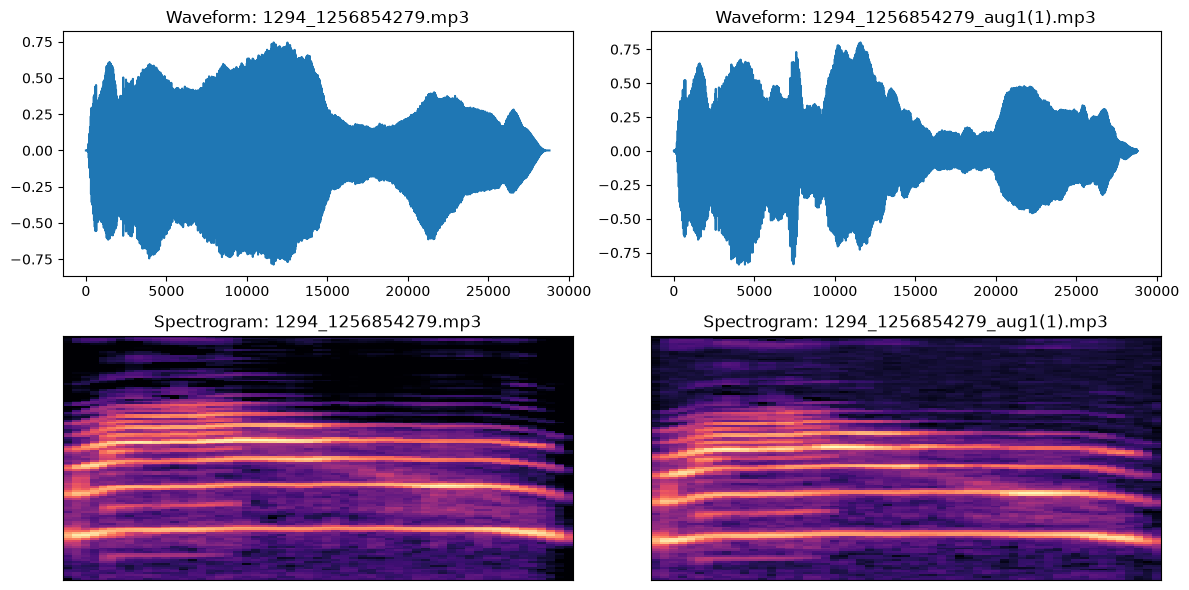

In [7]:
import matplotlib.pyplot as plt
import librosa.display

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, filename in enumerate(processed_files[:2]):
    path = os.path.join(folder, filename)
    audio, sr = librosa.load(path, sr=32000, mono=True)

    axes[0, i].plot(audio)
    axes[0, i].set_title(f"Waveform: {filename}")

    spec = librosa.feature.melspectrogram(y=audio, sr=sr)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    img = librosa.display.specshow(spec_db, sr=sr, ax=axes[1, i])
    axes[1, i].set_title(f"Spectrogram: {filename}")

plt.tight_layout()
plt.show()

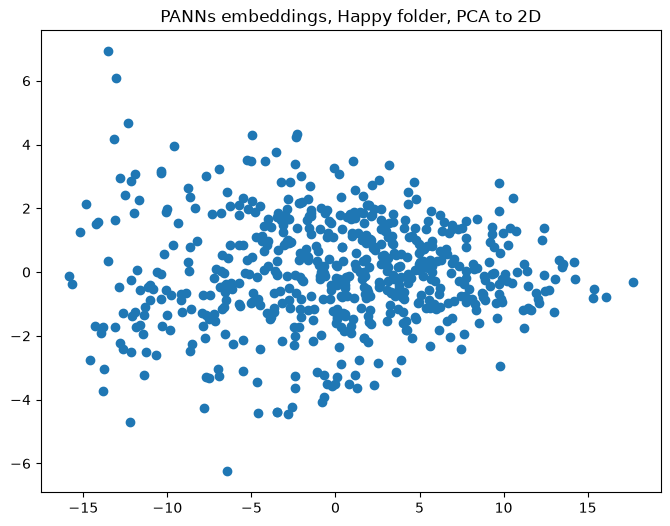

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.title("PANNs embeddings, Happy folder, PCA to 2D")
plt.show()

In [1]:
import pandas as pd

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df.insert(0, "filename", processed_files)

df

NameError: name 'X' is not defined